In [22]:
print("Hello, Seoul bikes!")

Hello, Seoul bikes!


In [23]:
2 + 3

5

In [24]:
import pandas as pd

In [25]:
   # Seoul Bike Sharing Demand dataset
   # Source: UCI Machine Learning Repository, licence CC BY 4.0
   url = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
   df = pd.read_csv(url, encoding="latin1")

In [26]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [27]:
df.shape

(8760, 14)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [29]:
df['Functioning Day'].value_counts()

,count
Functioning Day,
Yes,8465
No,295


In [30]:
df[df["Functioning Day"] == "No"]["Rented Bike Count"].sum()

np.int64(0)

In [31]:
# Keep only hours when the bike system was running
df_clean = df[df["Functioning Day"] == "Yes"].copy()
df_clean.shape

(8465, 14)

In [32]:
# Convert Date from text into a real date (day/month/year)
df_clean["Date"] = pd.to_datetime(df_clean["Date"],format="%d/%m/%Y")

In [33]:
# Add new coulmns for month and day of the week
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Weekday"] = df_clean["Date"].dt.day_name()
df_clean.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Month,Weekday
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday


In [34]:
   # Average number of bikes rented at each hour of the day
   hourly = df_clean.groupby("Hour")["Rented Bike Count"].mean()
   hourly

,Rented Bike Count
Hour,
0,561.457386
1,441.923295
2,312.769886
3,210.840909
4,137.488636
5,144.218750
6,298.184659
7,626.606232
8,1050.229462


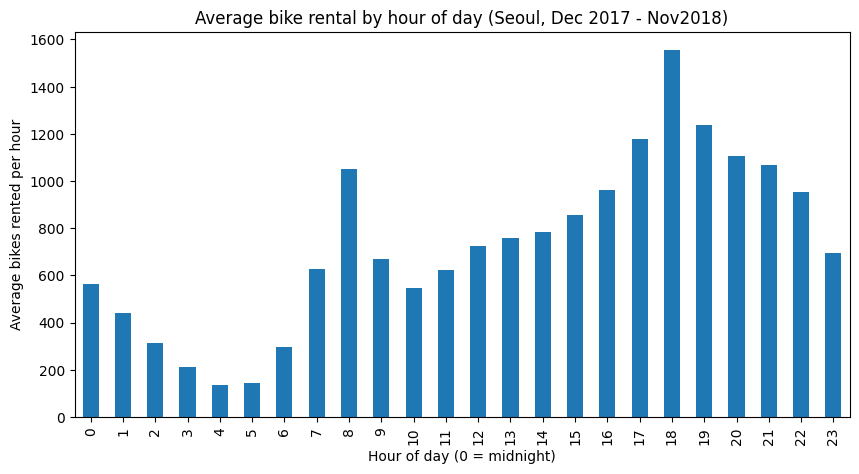

In [35]:
   import matplotlib.pyplot as plt

   hourly.plot(kind="bar", figsize=(10,5))
   plt.title("Average bike rental by hour of day (Seoul, Dec 2017 - Nov2018)")
   plt.xlabel("Hour of day (0 = midnight)")
   plt.ylabel("Average bikes rented per hour")
   plt.show()



In [36]:
# Label each hour as "Weekday" or "Weekend"
is_weekend = df_clean["Weekday"].isin(["Saturday", "Sunday"])
df_clean["Day Type"] = is_weekend.map({True:"Weekend", False: "Weekday"})
df_clean["Day Type"].value_counts()

,count
Day Type,
Weekday,6024
Weekend,2441


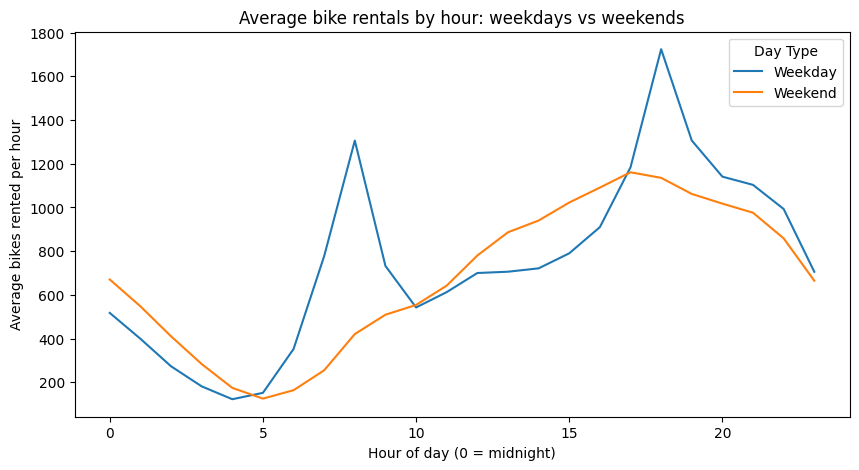

In [49]:
# Average rental by hour, split into weekday vs weekend
by_daytype = df_clean.groupby(["Hour", "Day Type"])["Rented Bike Count"].mean().unstack()

by_daytype.plot(figsize= (10,5))
plt.title("Average bike rentals by hour: weekdays vs weekends")
plt.xlabel("Hour of day (0 = midnight)")
plt.ylabel("Average bikes rented per hour")
plt.savefig("images/weekday_vs_weekend.png", dpi=150, bbox_inches="tight")
plt.show()


## Finding 1 : Time of day
- Weekends have two peaks. Rentals rise slowly to their highest around 4pm.
- This pattern is consisten with commuting on weekdays, but the data can't show why people ride.

In [38]:
   # Sort each hour's temperature into a 10-degree band
   bands = [-20, -10, 0, 10, 20, 30, 40]
   band_names = ["-20 to -10", "-10 to 0", "0 to 10", "10 to 20", "20 to 30", "30 to 40"]
   df_clean["Temp Band"] = pd.cut(df_clean["Temperature(°C)"], bins=bands, labels=band_names)
   df_clean["Temp Band"].value_counts().sort_index()

,count
Temp Band,
-20 to -10,228
-10 to 0,1226
0 to 10,2117
10 to 20,2058
20 to 30,2324
30 to 40,512


In [53]:
   # Average rentals in each temperature band
   temp_avg = df_clean.groupby("Temp Band", observed=True)["Rented Bike Count"].mean()

   temp_avg.plot(kind="bar", figsize=(10, 5))
   plt.title("Average bike rentals by temperature (Seoul, Dec 2017 – Nov 2018)")
   plt.xlabel("Temperature band (°C)")
   plt.ylabel("Average bikes rented per hour")
   plt.xticks(rotation=0)

   plt.show()


IndentationError: unexpected indent (1927045596.py, line 11)

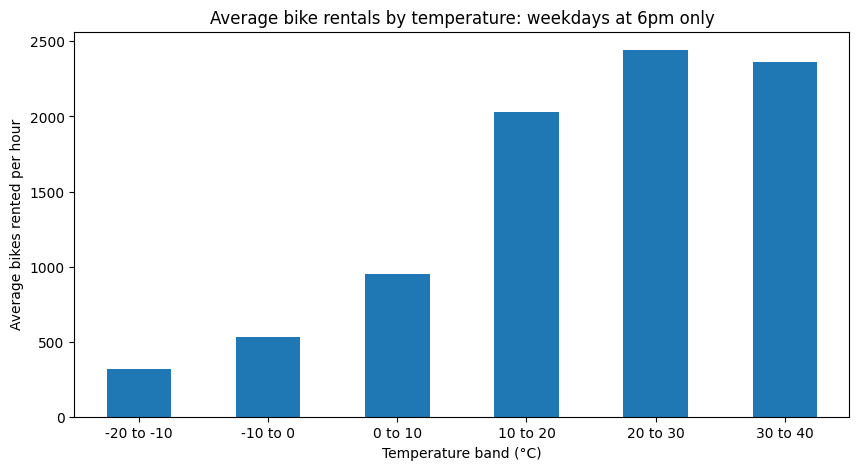

In [55]:
   # Fairer test: only weekday hours at 6pm, so time of day is the same
   six_pm = df_clean[(df_clean["Hour"] == 18) & (df_clean["Day Type"] == "Weekday")]
   six_pm_temp = six_pm.groupby("Temp Band", observed=True)["Rented Bike Count"].mean()

   six_pm_temp.plot(kind="bar", figsize=(10, 5))
   plt.title("Average bike rentals by temperature: weekdays at 6pm only")
   plt.xlabel("Temperature band (°C)")
   plt.ylabel("Average bikes rented per hour")
   plt.xticks(rotation=0)
   plt.savefig("images/temperature_6pm.png", dpi=150, bbox_inches="tight")
   plt.show()

## Findings 2: Temperature
- Rentals are higher in warmer temperatures.
- This still holds when comparing only weekdays at 67pm, so it isn't only explained by time of day.
- Limitation: warm hours also have more daylight and happen in summer, so the data can't separte temperature from these.


In [41]:
# Label each hour as "Raining (any rain) or "Not raining
is_raining = df_clean["Rainfall(mm)"] > 0
df_clean["Rain"] = is_raining.map({True: "Raining", False: "Not raining"})
df_clean["Rain"].value_counts()

,count
Rain,
Not raining,7949
Raining,516


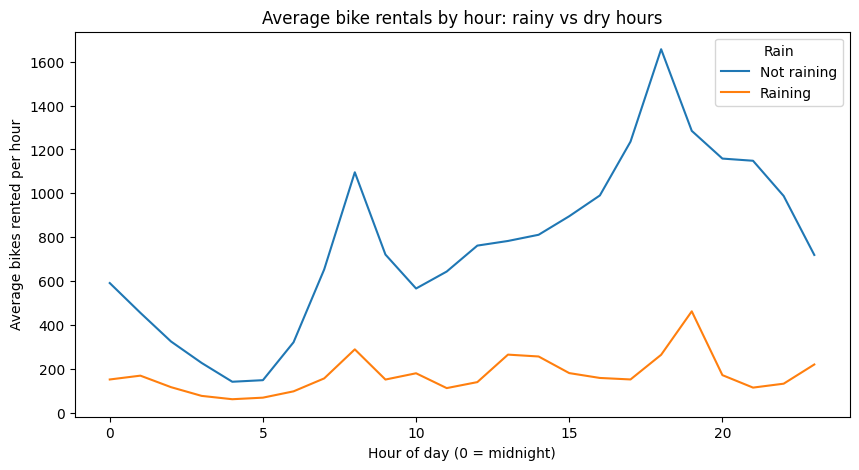

In [56]:
   # Average rentals by hour: rainy vs dry
   by_rain = df_clean.groupby(["Hour", "Rain"])["Rented Bike Count"].mean().unstack()

   by_rain.plot(figsize=(10, 5))
   plt.title("Average bike rentals by hour: rainy vs dry hours")
   plt.xlabel("Hour of day (0 = midnight)")
   plt.ylabel("Average bikes rented per hour")
   plt.savefig("images/rain_vs_dry.png", dpi=150, bbox_inches="tight")
   plt.show()

In [44]:
# Average rentlas in rainy vs dry hours
rain_avg = df_clean.groupby("Rain")["Rented Bike Count"].mean()
print(rain_avg)

# How much lower is it when raining, as a percentage?
drop = (1 - rain_avg["Raining"] / rain_avg["Not raining"]) * 100
print(f"Rainy hours have {drop:.0f}% fewer rentals on average")


Rain
Not raining    765.632029
Raining        167.257752
Name: Rented Bike Count, dtype: float64
Rainy hours have 78% fewer rentals on average


## Finding 3: Rain
- Rainy hours have 78% fewer rentals on average than dry hours
- Rentals are lower during rain at every hour of the day, so this isn't explained by time of day
- Limitations: there are far fewer rainy hours, "raining" includes light drizzle and heavy rain, and rainy hours may also be colder or darker.

In [45]:
   import os
   os.makedirs("images", exist_ok=True)
